# Model met 3 features

Hier is eerste ontwerp van van het model waarbij we maar 3 features gebruiken, we hebben deze 3 features gekozen:

stm_prioriteit: Dit is de prioriteitsindicatie, dat zegt hoe belangrijk het is dat deze storing snel opgelost moet worden.   
stm_oorz_code: Dit is de oorzaak code, dat geeft aan wat de oorzaak is van de storing.   
stm_sap_meldtijd: Dit is de meldtijd, dat zegt hoelaat de melding is gemaakt.   
stm_aann_t_fh: Dit is onze zelf aangemaakte target variabele, dit is de duur van wanneer de aannemer op locatie is, tot de treinen weer rijden.

Om de target variabele te berekenen gebruiken we deze features:   
stm_aanntpl_dd: Datum wanneer aannemer op locatie is.    
stm_aanntpl_tijd: Tijd wanneer aannemer op locatie is.    
stm_fh_dd: Datum wanneer treinen weer rijden.    
stm_fh_tijd: Tijd waneer treinen weer rijden.   

Dit zijn de meetniveaus van de target en features:

stm_prioriteit: ordinaal   
stm_oorz_code: nominaal      
stm_sap_meldtijd: continu  
stm_aann_t_fh: continu    

stm_aanntpl_dd: continu    
stm_aanntpl_tijd: continu     
stm_fh_dd: continu     
stm_fh_tijd: continu  

Onderzoeksvraag: Kunnen wij met 3 features al een redelijk model maken die kan voorspellen hoelang het duurt voordat de treinen weer rijden. 
Omdat we voornamelijk continu en ordinaal als spreidingsmaten hebben, gaan we gebruik maken van lineare regression. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from datetime import datetime
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df = pd.read_csv("sap_storing_data_hu_project.csv", low_memory=False)

## Data verifiëren, omzetten en maken
Eerst kijken we of er duplicates in de dataset zitten

In [3]:
df["#stm_sap_meldnr"].duplicated().sum()

332045

Er zitten 298799 duplicates in, deze gaan we verwijderen

In [4]:
df = df.drop_duplicates(subset=["#stm_sap_meldnr"])

Nu willen we gaan checken of we de features kunnen vertrouwen. Bij de stm_prioriteit kunnen we uit meegegeven documenten bepalen dat deze feature tussen de 1.0 en 9.0 in hele getallen loopt. Om dat te checken gebruiken we deze staafdiagram:

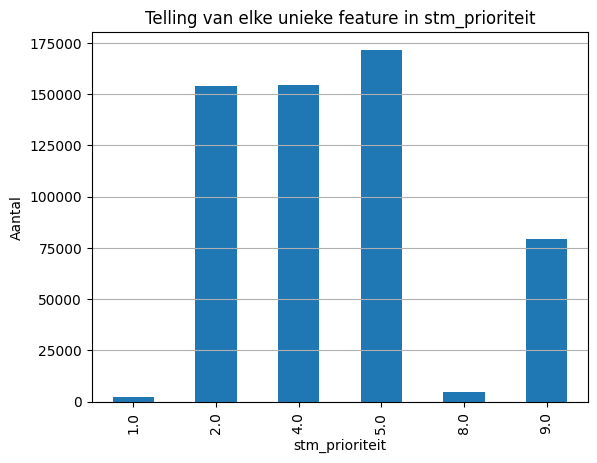

In [5]:
df['stm_prioriteit'].value_counts().sort_index().plot(kind='bar')

plt.title('Telling van elke unieke feature in stm_prioriteit')
plt.xlabel('stm_prioriteit')
plt.ylabel('Aantal')
plt.grid(axis='y')

Hier kunnen we zien dat wat in het megegeven document staat klopt, en er zitten geen values tussen, dus de data uit deze feature kunnen we vertrouwen. Ook hoeven we deze data niet om te zetten, omdat deze ordinaal is. 

Wat we well moeten doen is alle rijen verwijderen die prioriteit als 9.0 hebben. Deze betekenen dat er geen aannemer naar toe hoeft. Dus is er geen lang genoege storing om dit in de dataset te houden.

In [6]:
df = df[~df["stm_prioriteit"].isin([9.0])]
df["stm_prioriteit"].describe()

count    487039.000000
mean          3.741719
std           1.319368
min           1.000000
25%           2.000000
50%           4.000000
75%           5.000000
max           8.000000
Name: stm_prioriteit, dtype: float64

De max is nu 8.0, dit betekent dat alle rijen met prioriteit als 9.0 verwijderd zijn.

Bij de stm_oorz_code kunnen ook uit een meegegeven document vaststellen wat de verschillende oorzaak codes zijn. Om te kijken of er niet rare values in de kolom zitten, zullen we alle unieke values uit stm_oorz_code	halen, en handmatig checken of die allemaal in het document staan.

In [7]:
df = df.dropna(subset=["stm_prioriteit", "stm_oorz_code", "stm_sap_meldtijd"])
data = df[["stm_prioriteit", "stm_oorz_code", "stm_sap_meldtijd"]]
print(set(list(data["stm_oorz_code"])))

{130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 150.0, 151.0, 154.0, 33.0, 294.0, 298.0, 299.0, 48.0, 51.0, 180.0, 181.0, 182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188.0, 189.0, 201.0, 202.0, 203.0, 204.0, 205.0, 206.0, 207.0, 208.0, 209.0, 210.0, 211.0, 212.0, 213.0, 214.0, 215.0, 218.0, 219.0, 220.0, 221.0, 222.0, 223.0, 224.0, 225.0, 226.0, 227.0, 228.0, 229.0, 230.0, 999.0, 231.0, 233.0, 234.0, 235.0, 239.0, 240.0, 241.0, 242.0, 250.0}


De volgende values uit die lijst die niet in het document staan zijn: 33, 48, 51 en 999, deze gaan we onderzoeken waarom deze in de dataset staan

In [8]:
data["stm_oorz_code"].value_counts().loc[[33.0, 48.0, 51.0, 999.0]]

stm_oorz_code
33.0       1
48.0       1
51.0       1
999.0    101
Name: count, dtype: int64

Nu zien we dat 33, 48 en 51 allemaal 1 keer voorkomen, deze zijn dus fouten in de dataset. Deze gaan we verwijderen.
999 komt 102 keer voor, dit is een typische waarde die wordt ingevoerd als de orzaakscode niet duidelijk is. Deze verwijderen we ook.

In [9]:
data = data[~data["stm_oorz_code"].isin([33.0, 48.0, 51.0, 999.0])]
data["stm_oorz_code"].describe()

count    451442.000000
mean        202.007452
std          46.810553
min         130.000000
25%         150.000000
50%         215.000000
75%         221.000000
max         299.000000
Name: stm_oorz_code, dtype: float64

We kunnen nu zien dat de min en max van stm_oorz_code valt binnen de values in het meegegeven document.

Omdat deze feature nominaal is, moeten we dit met get_dummies() om gaan zetten:

In [10]:
dummies = pd.get_dummies(data['stm_oorz_code'], prefix='Index')
dummies = dummies.astype(int)

data = pd.concat([data, dummies], axis=1)
data.columns

Index(['stm_prioriteit', 'stm_oorz_code', 'stm_sap_meldtijd', 'Index_130.0',
       'Index_131.0', 'Index_132.0', 'Index_133.0', 'Index_134.0',
       'Index_135.0', 'Index_136.0', 'Index_139.0', 'Index_140.0',
       'Index_141.0', 'Index_142.0', 'Index_143.0', 'Index_144.0',
       'Index_145.0', 'Index_146.0', 'Index_147.0', 'Index_148.0',
       'Index_149.0', 'Index_150.0', 'Index_151.0', 'Index_154.0',
       'Index_180.0', 'Index_181.0', 'Index_182.0', 'Index_183.0',
       'Index_184.0', 'Index_185.0', 'Index_186.0', 'Index_187.0',
       'Index_188.0', 'Index_189.0', 'Index_201.0', 'Index_202.0',
       'Index_203.0', 'Index_204.0', 'Index_205.0', 'Index_206.0',
       'Index_207.0', 'Index_208.0', 'Index_209.0', 'Index_210.0',
       'Index_211.0', 'Index_212.0', 'Index_213.0', 'Index_214.0',
       'Index_215.0', 'Index_218.0', 'Index_219.0', 'Index_220.0',
       'Index_221.0', 'Index_222.0', 'Index_223.0', 'Index_224.0',
       'Index_225.0', 'Index_226.0', 'Index_227.0', 

Hier zien we die nieuwe kolommen die aangemaakt zijn met get_dummies()

Bij stm_sap_meldtijd kunnen we valse tijden hebben, die staan dan als "::" zoals hieronder te zien is. Deze gaan we verwijderen: 

In [11]:
len(data[data["stm_sap_meldtijd"] == "::"])

58

In [12]:
# Verwijderen door alles te verwijderen wat niet lengte 8 is, wat de lengte van de format van de tijd is. (14:00:00)
data = data.dropna(subset=["stm_sap_meldtijd"])
data = data[data["stm_sap_meldtijd"].apply(lambda x: len(x) == 8)]

Omdat de values in deze feature als string staan, moeten we deze omzetten naar een float. Daarom zetten we de stm_sap_meldtijd om naar minuten. Dit zijn dus hoeveel minuten er op dag voorbij zijn gegaan sinds middennacht.

In [13]:
for index, i in data["stm_sap_meldtijd"].items():
    time_lst = i.split(":") 
    time_in_min = float(time_lst[0]) * 60 + float(time_lst[1]) + float(time_lst[2]) / 60
    data.at[index, "stm_sap_meldtijd"] = time_in_min

In [14]:
data["stm_sap_meldtijd"] = pd.to_numeric(data["stm_sap_meldtijd"])

data["stm_sap_meldtijd"].describe()

count    451384.000000
mean        757.627400
std         335.613709
min           0.000000
25%         527.000000
50%         750.000000
75%         999.000000
max        1439.983333
Name: stm_sap_meldtijd, dtype: float64

Alle tijden staan nu in minuten, nu gaan we de target aanmaken 

In [15]:
df1 = df[["stm_aanntpl_dd", "stm_aanntpl_tijd", "stm_fh_dd", "stm_fh_tijd"]].dropna()

df1["stm_aanntpl_dd"] = pd.to_datetime(df1["stm_aanntpl_dd"], format="%d/%m/%Y", errors='coerce')
df1["stm_fh_dd"] = pd.to_datetime(df1["stm_fh_dd"], format="%d/%m/%Y", errors='coerce')

df1["stm_fh_tijd"] = pd.to_datetime(df1["stm_fh_tijd"], format="%H:%M:%S", errors='coerce')
df1["stm_aanntpl_tijd"] = pd.to_datetime(df1["stm_aanntpl_tijd"], format="%H:%M:%S", errors='coerce')

dagen_verschil = ((df1["stm_fh_dd"] - df1["stm_aanntpl_dd"]).dt.days) * 24 * 60
tijden_verschil = (df1["stm_fh_tijd"] - df1["stm_aanntpl_tijd"]).dt.total_seconds() / 60

data["stm_aann_t_fh"] = dagen_verschil + tijden_verschil

data = data.dropna(subset=["stm_aann_t_fh"])

data[["stm_prioriteit", "stm_aann_t_fh", "stm_sap_meldtijd"]].describe()

,stm_prioriteit,stm_aann_t_fh,stm_sap_meldtijd
count,417218.000000,4.172180e+05,417218.000000
mean,3.689174,4.755797e+02,755.229328
std,1.350328,1.083822e+04,335.081066
min,1.000000,-1.167949e+05,0.000000
25%,2.000000,1.006667e+01,526.000000
50%,4.000000,3.200000e+01,747.000000
75%,5.000000,7.600000e+01,995.000000
max,8.000000,4.211280e+06,1439.983333


In [16]:
data["stm_aann_t_fh"].describe()

count    4.172180e+05
mean     4.755797e+02
std      1.083822e+04
min     -1.167949e+05
25%      1.006667e+01
50%      3.200000e+01
75%      7.600000e+01
max      4.211280e+06
Name: stm_aann_t_fh, dtype: float64

Zoals we zien is de max heel hoog en is de min een min getal, uit het interview hebben we de tips gekregen om alles onder de 5 minuten en boven de 8 uur weg te halen.

In [17]:
data = data[data["stm_aann_t_fh"] <= (8 * 60)] # 8 uur
data = data[data["stm_aann_t_fh"] >= 5] # 5 minuten
data[["stm_prioriteit", "stm_aann_t_fh", "stm_sap_meldtijd"]].describe()

,stm_prioriteit,stm_aann_t_fh,stm_sap_meldtijd
count,334174.000000,334174.000000,334174.000000
mean,3.682710,66.688442,752.864500
std,1.357687,73.910845,335.837374
min,1.000000,5.000000,0.000000
25%,2.000000,20.000000,522.000000
50%,4.000000,41.000000,743.000000
75%,5.000000,83.000000,995.000000
max,8.000000,480.000000,1439.983333


Nu de data klaar is, kunnen we een model gaan maken

## Model

Als eerst maken we een baseline model met de mediaan en het gemiddelde:

In [28]:
median = data[["stm_aann_t_fh"]].median()   

baseline = [median] * len(data)
    
r2_baseline = r2_score(data['stm_aann_t_fh'], baseline)
    
rmse_baseline = np.sqrt(mean_squared_error(data['stm_aann_t_fh'], baseline))

print(f"R2: {r2_baseline}, RMSE: {rmse_baseline}")

R2: -0.1207982081405734, RMSE: 78.24763657635937


Met een score Baseline van -0.1207982081405734, kunnen we vastellen dat het gemiddelde een betere manier is om de stm_aann_t_fh te voorspellen dan de mediaan. Dit kunnen we zeggen omdat de score Baseline een negatief getal is.

Nu maken we het officiele model

In [25]:
model = LinearRegression()
    
x_train, x_test, y_train, y_test = train_test_split(data[['stm_prioriteit', 'stm_sap_meldtijd', 'Index_130.0',
           'Index_131.0', 'Index_132.0', 'Index_133.0', 'Index_134.0',
           'Index_135.0', 'Index_136.0', 'Index_139.0', 'Index_140.0',
           'Index_141.0', 'Index_142.0', 'Index_143.0', 'Index_144.0',
           'Index_145.0', 'Index_146.0', 'Index_147.0', 'Index_148.0',
           'Index_149.0', 'Index_150.0', 'Index_151.0', 'Index_154.0',
           'Index_180.0', 'Index_181.0', 'Index_182.0', 'Index_183.0',
           'Index_184.0', 'Index_185.0', 'Index_186.0', 'Index_187.0',
           'Index_188.0', 'Index_189.0', 'Index_201.0',
           'Index_202.0', 'Index_203.0', 'Index_204.0', 'Index_205.0',
           'Index_206.0', 'Index_207.0', 'Index_208.0', 'Index_209.0',
           'Index_210.0', 'Index_211.0', 'Index_212.0', 'Index_213.0',
           'Index_214.0', 'Index_215.0', 'Index_218.0', 'Index_219.0',
           'Index_220.0', 'Index_221.0', 'Index_222.0', 'Index_223.0',
           'Index_224.0', 'Index_225.0', 'Index_226.0', 'Index_227.0',
           'Index_228.0', 'Index_229.0', 'Index_230.0', 'Index_231.0',
           'Index_233.0', 'Index_234.0', 'Index_235.0', 'Index_239.0',
           'Index_240.0', 'Index_241.0', 'Index_242.0', 'Index_250.0',
           'Index_294.0', 'Index_298.0', 'Index_299.0']], data["stm_aann_t_fh"], test_size = 0.20, random_state = 10)
    
model.fit(x_train, y_train)
    
y_pred = model.predict(x_test)
    
print("R2 score:", r2_score(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score: 0.05305904036375575
Root Mean Squared Error: 71.82289711973256


## Conclusie
Het model met 3 features met een r2 score van 0.06313805426901808  is niet goed genoeg om de target te voorspellen.